In [2]:
!nvidia-smi

Wed Aug 26 05:42:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-08-26 05:52:11--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-26 05:52:12 ERROR 404: Not Found.



In [9]:
import os

# The model.tflite is located in the current working directory
file_path = os.path.join(os.getcwd(), "model.tflite")
print(f"The model .tflite file is saved at: {file_path}")

The model .tflite file is saved at: /content/model.tflite


In [12]:
!unzip fruits.zip

Archive:  fruits.zip
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: fruits/test/apple/

In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2


In [15]:
import tensorflow as tf

img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/fruits/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/fruits/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/fruits/test",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Using 368 files for training.
Found 460 files belonging to 3 classes.
Using 92 files for validation.
Found 130 files belonging to 3 classes.


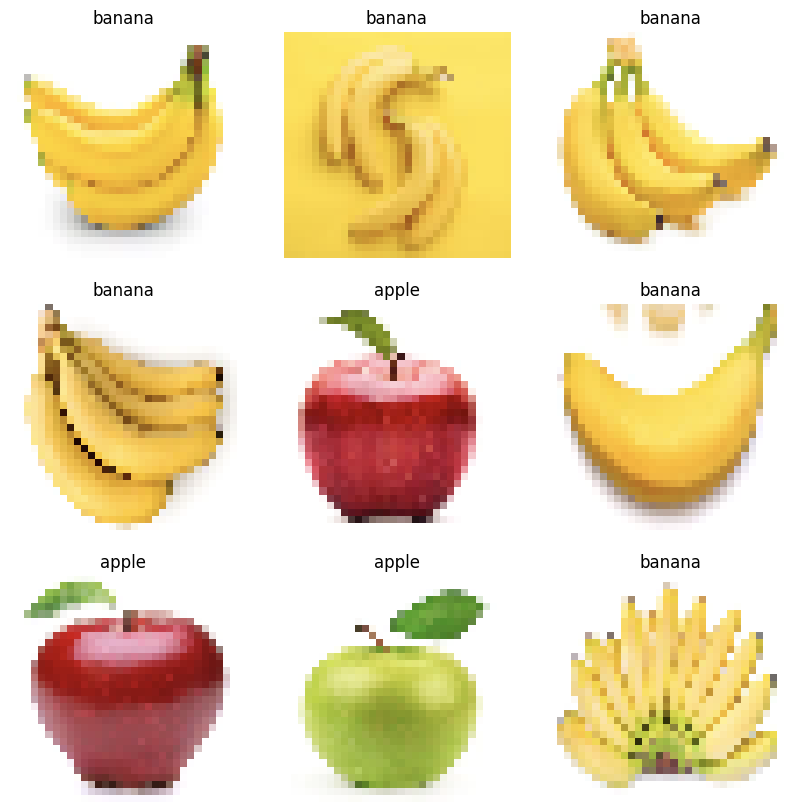

In [16]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [17]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32,3,activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation="relu"),
        tf.keras.layers.Dense(3)
    ]
)

In [18]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [19]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.5380 - loss: 1.0097 - val_accuracy: 0.6630 - val_loss: 0.8449
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7446 - loss: 0.6835 - val_accuracy: 0.8804 - val_loss: 0.4702
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8668 - loss: 0.3932 - val_accuracy: 0.8152 - val_loss: 0.4145
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8696 - loss: 0.3096 - val_accuracy: 0.9022 - val_loss: 0.2995
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9049 - loss: 0.2562 - val_accuracy: 0.8696 - val_loss: 0.2674
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9049 - loss: 0.2234 - val_accuracy: 0.8587 - val_loss: 0.2860
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9348 - loss: 0.1871 - val_accuracy: 0.9457 - val_loss: 0.1827
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9321 - loss: 0.1740 - val_accuracy: 0.9239 -

In [20]:
convertor = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = convertor.convert()

with open("model.tflite","wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpxuihkdlx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133174409484944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409486096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409486288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409485136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409485904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409486864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409487632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409487824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409487440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133174409488016: TensorSpec(shape=(), dtype=tf.resource, name=None)
